In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.mission_profile import mission_profile

In [2]:
def plot_profile(profile):
    fig = plt.figure()
    fig.set_size_inches(15,8)
    fig.subplots_adjust(0.2,0.001)
    
    # Plot 1 y vs x
    ax = fig.add_subplot(2,2,1)
    ax.plot(profile.x_coords,profile.y_coords)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(profile.name + ' y vs. x')
    
    # Plot 2 y vs t
    ax = fig.add_subplot(2,2,2)
    ax.plot(profile.t_values,profile.y_coords)
    ax.set_xlabel('t (s)')
    ax.set_ylabel('y (m)')
    ax.set_title(profile.name + ' y vs. t')
    
   
    # this is code to test the interpolator 
    # I will get rid of it when I have a real use for the interpolator
    y_points = np.array([])
    t_points = np.array([])
    for i in np.arange(0, 1, 0.05):
        t = i * profile.t_values[-1] # Range between 0 and max time
        x,y,v_x,v_y,name = profile.time_solve(t)

        ax.annotate(name, (t, y))
        
        t_points = np.append(t_points,t)
        y_points = np.append(y_points,y)
        
    ax.scatter(t_points,y_points,s=30)

    # Plotting V is more difficult because it is a stepwise function so you have to plot the same time twice
    t = np.array([])
    v_x = np.array([])
    v_y = np.array([])
    
    for i in range(len(profile.v_y_values)):
        t = np.append(t, profile.t_values[i])
        t = np.append(t, profile.t_values[i+1])
        v_x = np.append(v_x, profile.v_x_values[i])
        v_x = np.append(v_x, profile.v_x_values[i])
        v_y = np.append(v_y, profile.v_y_values[i])
        v_y = np.append(v_y, profile.v_y_values[i])
    
    # Plot 3 vy vs t
    ax = fig.add_subplot(2,2,3)
    ax.plot(t,v_y)
    ax.set_xlabel('t (s)')
    ax.set_ylabel('v_y (m/s)')
    ax.set_title(profile.name + ' v_y  vs. t (s)')

    # Plot 4 vx vs t
    ax = fig.add_subplot(2,2,4)
    ax.plot(t,v_x)
    ax.set_xlabel('t (s)')
    ax.set_ylabel('v_x (m/s)')
    ax.set_title(profile.name + ' v_x vs. t ')
    
    plt.show()

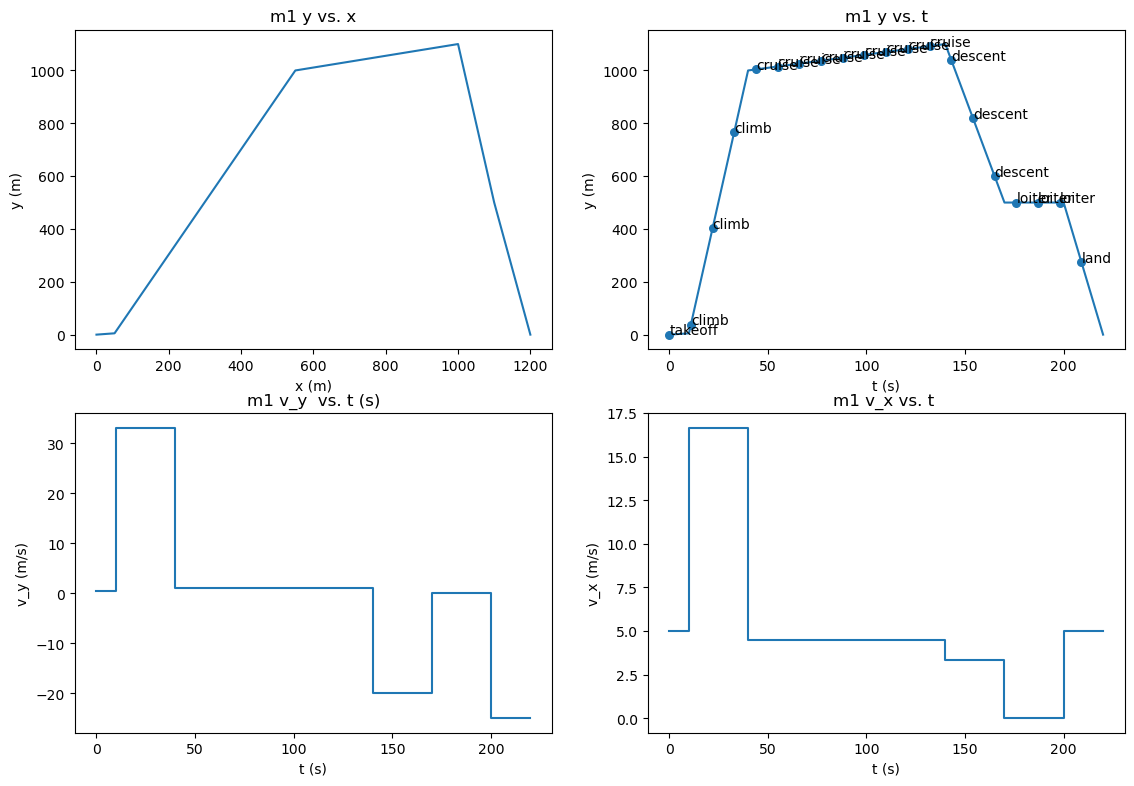

In [3]:

m1 = mission_profile("m1",50)
m1.add_segment("takeoff",10,50,5)
m1.add_segment("climb",30,550,1000)
m1.add_segment("cruise",100,1000,1100)
m1.add_segment("descent",30,1100,500)
m1.add_segment("loiter",30)
m1.add_segment("land",20,1200,0)

plot_profile(m1)

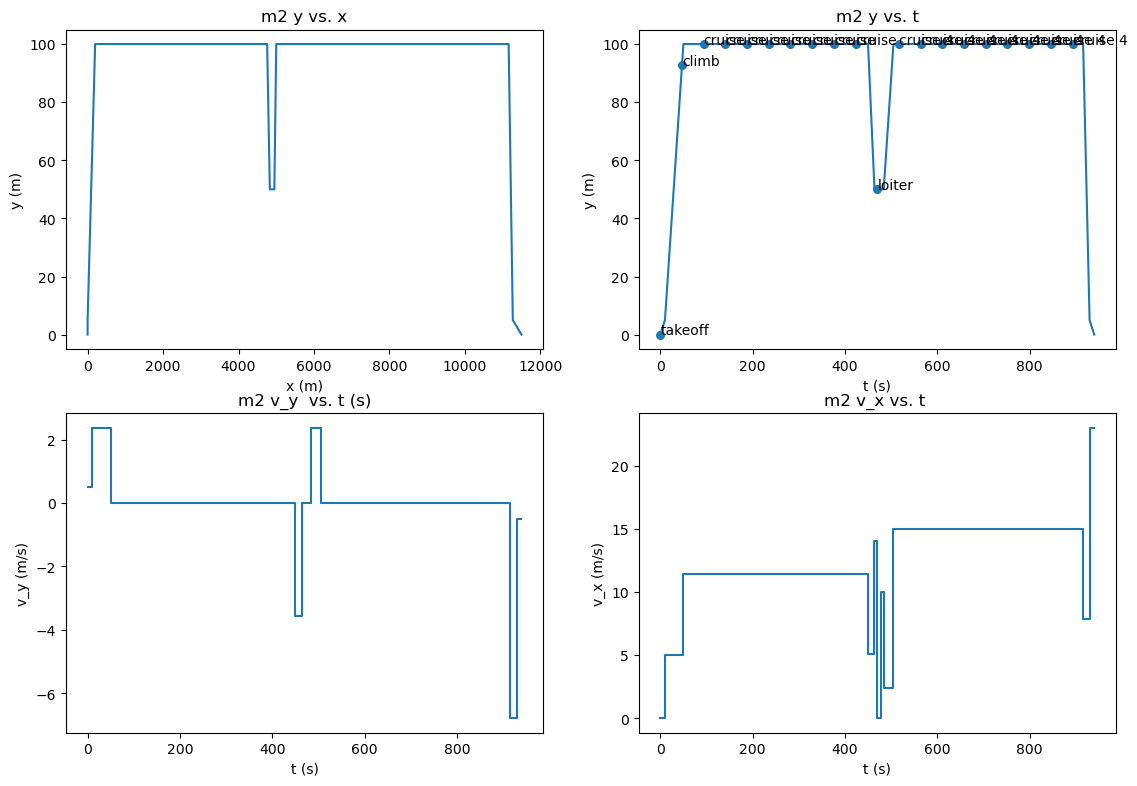

[100 100 100 100 100 100  50  50  50  50  50  50  50]


In [5]:
# Sample Profile

m2 = mission_profile("m2",100)
m2.add_segment("takeoff",10,0,5)
m2.add_segment("climb",40,200,100)
m2.add_segment("cruise",400,4759,100)
m2.add_segment("descent",14,4830,50)
m2.add_segment("cruise 2",5,4900,50)
m2.add_segment("loiter",5)
m2.drop_payload(50)
m2.add_segment("loiter",5)
m2.add_segment("cruise 3",5,4950,50)
m2.add_segment("climb 2",21,5000,100)
m2.add_segment("cruise 4",411,11160,100)
m2.add_segment("descent 2",14,11270,5)
m2.add_segment("land",10,11500,0)
plot_profile(m2)

print(m2.payload)
